In [6]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/COVID_19_dataset.zip', 'r') as z:
  z.extractall('/content/dataset')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6bf48957d7c51c6b3459fd376148cbd99f62153f3c9728d59920912a8743bfb8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

In [12]:
train_path = '/content/dataset/COVID_19_dataset/train'
val_path   = '/content/dataset/COVID_19_dataset/val'
test_path  = '/content/dataset/COVID_19_dataset/test'
CLASSES = ['COVID','Normal','Viral Pneumonia']

In [14]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_path, transform=transform)
val_data = datasets.ImageFolder(val_path, transform=transform)
test_data = datasets.ImageFolder(test_path, transform=transform)

def filter_classes(dataset, valid_classes):
  valid_idx = [i for i, (_, label) in enumerate(dataset.samples)
  if dataset.classes[label] in valid_classes]
  dataset.samples= [dataset.samples[i] for i in valid_idx]
  dataset.targets= [dataset.targets[i] for i in valid_idx]
  return dataset

train_data = filter_classes(train_data, CLASSES)
val_data = filter_classes(val_data, CLASSES)
test_data = filter_classes(test_data, CLASSES)

train_loader = DataLoader(train_data, batch_size=32, shuffle= True)
val_loader = DataLoader(val_data, batch_size=32, shuffle= False)
test_loader = DataLoader(test_data, batch_size=32, shuffle= False)

print("Classes found:", train_data.classes)
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Classes found: ['COVID', 'Normal', 'Viral Pneumonia']
Train: 3000 | Val: 600 | Test: 435


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Using: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]


In [16]:
EPOCHS = 10
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.3f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print("  Best model saved")

Epoch 1/10 | Loss: 0.197 | Val Acc: 97.67%
  Best model saved
Epoch 2/10 | Loss: 0.034 | Val Acc: 97.50%
Epoch 3/10 | Loss: 0.009 | Val Acc: 98.33%
  Best model saved
Epoch 4/10 | Loss: 0.005 | Val Acc: 97.50%
Epoch 5/10 | Loss: 0.010 | Val Acc: 98.33%
Epoch 6/10 | Loss: 0.023 | Val Acc: 95.00%
Epoch 7/10 | Loss: 0.031 | Val Acc: 96.83%
Epoch 8/10 | Loss: 0.015 | Val Acc: 97.50%
Epoch 9/10 | Loss: 0.010 | Val Acc: 97.50%
Epoch 10/10 | Loss: 0.022 | Val Acc: 98.00%


In [17]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

                 precision    recall  f1-score   support

          COVID       0.99      0.99      0.99       145
         Normal       0.99      0.99      0.99       145
Viral Pneumonia       1.00      0.99      1.00       145

       accuracy                           0.99       435
      macro avg       0.99      0.99      0.99       435
   weighted avg       0.99      0.99      0.99       435



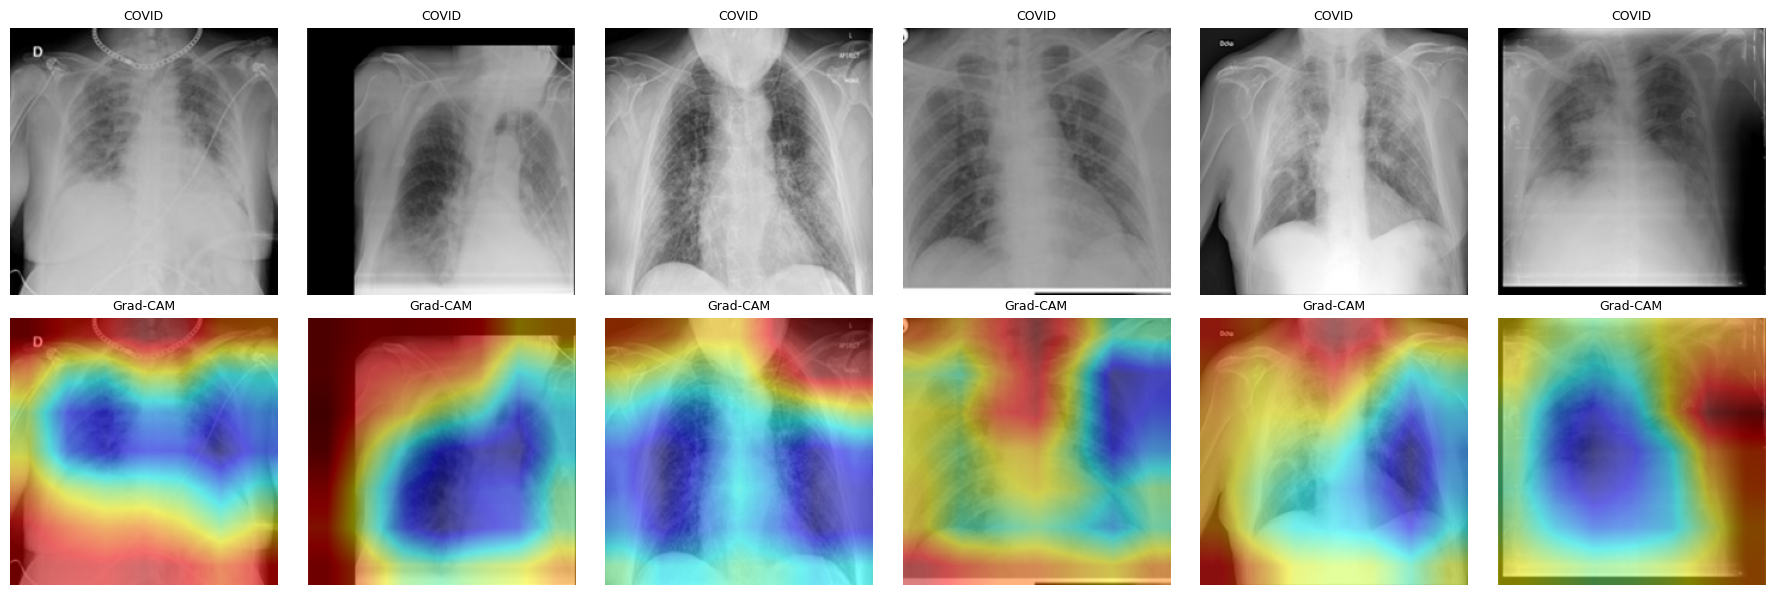

Saved gradcam_output.png


In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

sample_images = [test_data.samples[i][0] for i in range(6)]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for idx, img_path in enumerate(sample_images):
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    raw_np = np.array(raw) / 255.0

    input_tensor = transform(raw).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(raw_np.astype(np.float32), grayscale_cam)

    axes[0][idx].imshow(raw_np)
    axes[0][idx].set_title(CLASSES[test_data.samples[idx][1]], fontsize=9)
    axes[0][idx].axis('off')

    axes[1][idx].imshow(visualization)
    axes[1][idx].set_title('Grad-CAM', fontsize=9)
    axes[1][idx].axis('off')

plt.tight_layout()
plt.savefig('gradcam_output.png', dpi=150)
plt.show()
print("Saved gradcam_output.png")

100%|██████████| 32/32 [00:00<00:00, 53.57it/s]


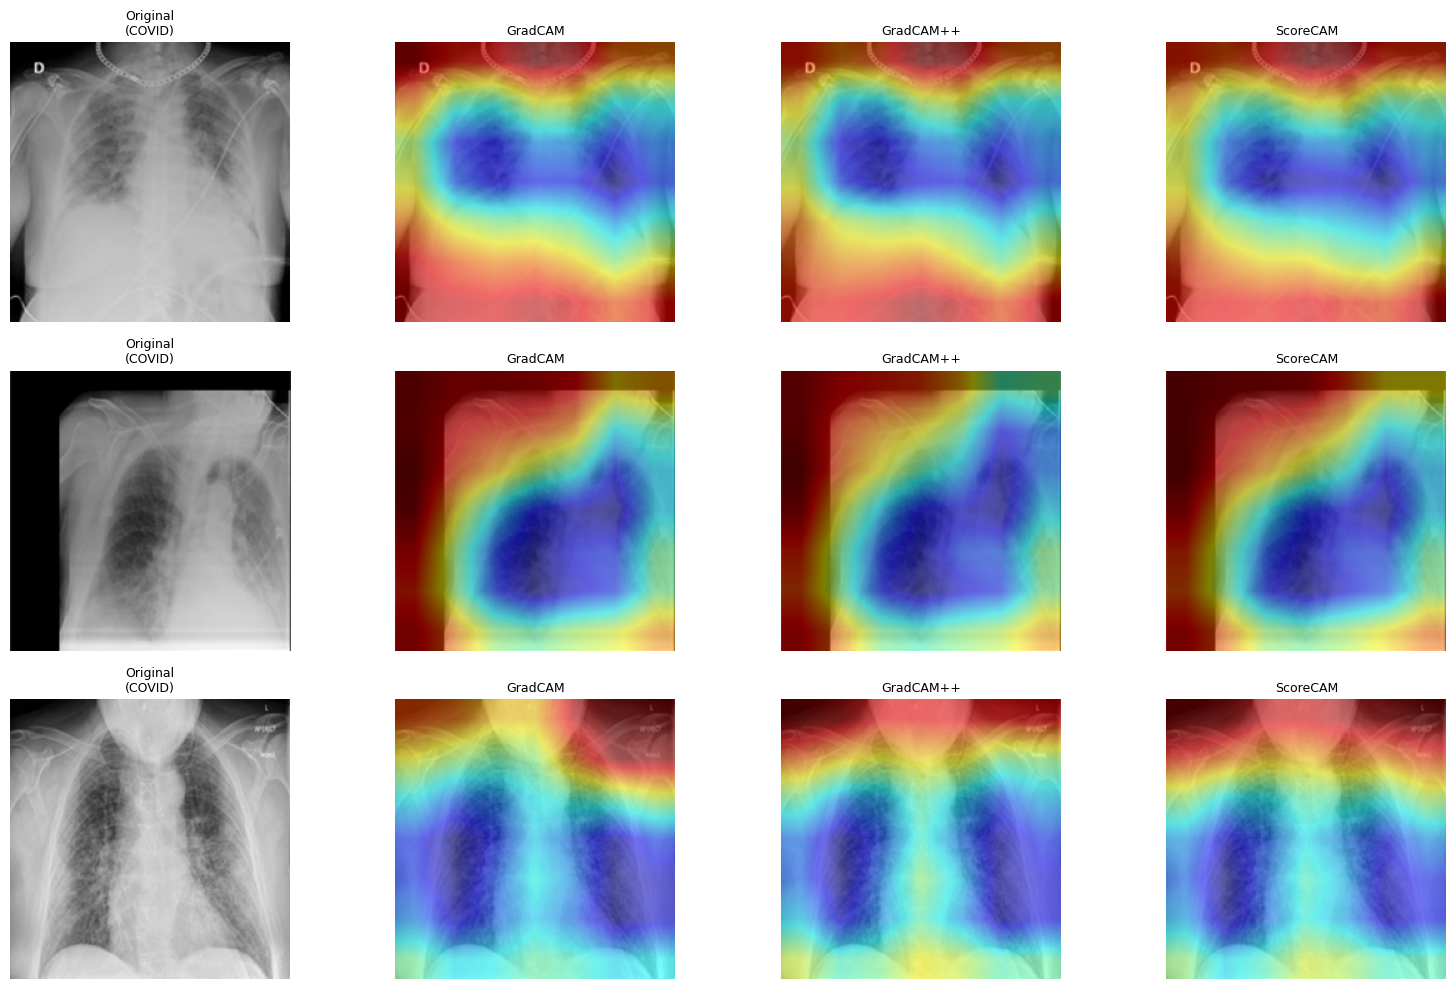

Saved all_methods_comparison.png


In [19]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM

methods = {
    'GradCAM': GradCAM(model=model, target_layers=target_layer),
    'GradCAM++': GradCAMPlusPlus(model=model, target_layers=target_layer),
    'ScoreCAM': ScoreCAM(model=model, target_layers=target_layer),
}

sample_images = [test_data.samples[i][0] for i in range(3)]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
col_titles = ['Original', 'GradCAM', 'GradCAM++', 'ScoreCAM']

for row, img_path in enumerate(sample_images):
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    raw_np = np.array(raw) / 255.0
    input_tensor = transform(raw).unsqueeze(0).to(device)
    label = CLASSES[test_data.samples[row][1]]

    axes[row][0].imshow(raw_np)
    axes[row][0].set_title(f'Original\n({label})', fontsize=9)
    axes[row][0].axis('off')

    for col, (name, cam_method) in enumerate(methods.items(), start=1):
        grayscale_cam = cam_method(input_tensor=input_tensor)[0]
        vis = show_cam_on_image(raw_np.astype(np.float32), grayscale_cam)
        axes[row][col].imshow(vis)
        axes[row][col].set_title(name, fontsize=9)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('all_methods_comparison.png', dpi=150)
plt.show()
print("Saved all_methods_comparison.png")

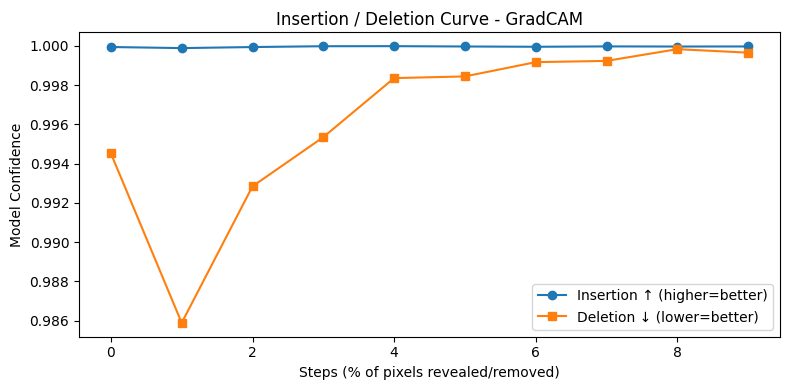

In [22]:
def insertion_deletion(model, img_tensor, cam_mask, device, steps=10):

    # measures how model confiednce changes upon insertion deltion of pixels in order of saliency importance

    model.eval()
    img = img_tensor.squeeze(0).cpu().numpy()
    flat_mask = cam_mask.flatten()
    sorted_idx = np.argsort(flat_mask)[::-1]

    insertion_scores, deletion_scores = [], []
    baseline = np.zeros_like(img)
    deleted  = img.copy()

    chunk = len(sorted_idx) // steps

    for step in range(1, steps + 1):
        top_k = sorted_idx[:step * chunk]
        row_idx = top_k // 224
        col_idx = top_k % 224

#insert
        inserted = baseline.copy()
        inserted[:, row_idx, col_idx] = img[:, row_idx, col_idx]
        ins_tensor = torch.tensor(inserted).unsqueeze(0).float().to(device)
        with torch.no_grad():
            ins_score = torch.softmax(model(ins_tensor), dim=1).max().item()
        insertion_scores.append(ins_score)
#delete
        deleted[:, row_idx, col_idx] = 0
        del_tensor = torch.tensor(deleted.copy()).unsqueeze(0).float().to(device)
        with torch.no_grad():
            del_score = torch.softmax(model(del_tensor), dim=1).max().item()
        deletion_scores.append(del_score)

    return insertion_scores, deletion_scores


img_path = test_data.samples[0][0]
raw = Image.open(img_path).convert('RGB').resize((224, 224))
raw_np = np.array(raw) / 255.0
input_tensor = transform(raw).unsqueeze(0).to(device)

cam_basic = GradCAM(model=model, target_layers=target_layer)
mask = cam_basic(input_tensor=input_tensor)[0]

ins, dels = insertion_deletion(model, input_tensor, mask, device)

plt.figure(figsize=(8, 4))
plt.plot(ins, label='Insertion ↑ (higher=better)', marker='o')
plt.plot(dels, label='Deletion ↓ (lower=better)', marker='s')
plt.xlabel('Steps (% of pixels revealed/removed)')
plt.ylabel('Model Confidence')
plt.title('Insertion / Deletion Curve - GradCAM')
plt.legend()
plt.tight_layout()
plt.savefig('insertion_deletion.png', dpi=150)
plt.show()

In [23]:
from scipy.stats import entropy as scipy_entropy

def saliency_entropy(cam_mask):
    """Lower entropy = more focused saliency map = better"""
    flat = cam_mask.flatten()
    flat = flat / (flat.sum() + 1e-8)
    return scipy_entropy(flat)

#Compare entropy across all 3 methods
entropy_results = {name: [] for name in methods}

for i in range(5):
    img_path = test_data.samples[i][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = transform(raw).unsqueeze(0).to(device)

    for name, cam_method in methods.items():
        mask = cam_method(input_tensor=input_tensor)[0]
        entropy_results[name].append(saliency_entropy(mask))

print("Average Saliency Entropy (lower = more focused):")
for name, scores in entropy_results.items():
    print(f"  {name:12s}: {np.mean(scores):.4f}")

100%|██████████| 32/32 [00:00<00:00, 50.64it/s]

Average Saliency Entropy (lower = more focused):
  GradCAM     : 10.6638
  GradCAM++   : 10.6850
  ScoreCAM    : 10.6677


In [24]:
def aopc(model, img_tensor, cam_mask, device, steps=10):
    #AOPC (Area Over Perturbation Curve): Measures average confidence drop as we remove top salient pixels.
    #Higher AOPC shows that saliency map is more faithful to model decisions.

    model.eval()
    img = img_tensor.squeeze(0).cpu().numpy()
    flat_mask = cam_mask.flatten()
    sorted_idx = np.argsort(flat_mask)[::-1]

    with torch.no_grad():
        original_conf = torch.softmax(model(img_tensor), dim=1).max().item()

    drops = []
    perturbed = img.copy()
    chunk = len(sorted_idx) // steps

    for step in range(1, steps + 1):
        top_k = sorted_idx[:step * chunk]
        row_idx = top_k // 224
        col_idx = top_k % 224
        perturbed[:, row_idx, col_idx] = 0
        p_tensor = torch.tensor(perturbed.copy()).unsqueeze(0).float().to(device)
        with torch.no_grad():
            conf = torch.softmax(model(p_tensor), dim=1).max().item()
        drops.append(original_conf - conf)

    return np.mean(drops)

#Compare AOPC across methods for 5 images
aopc_results = {name: [] for name in methods}

for i in range(5):
    img_path = test_data.samples[i][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = transform(raw).unsqueeze(0).to(device)

    for name, cam_method in methods.items():
        mask = cam_method(input_tensor=input_tensor)[0]
        score = aopc(model, input_tensor, mask, device)
        aopc_results[name].append(score)

print("Average AOPC (higher = better saliency map):")
for name, scores in aopc_results.items():
    print(f"  {name:12s}: {np.mean(scores):.4f}")

100%|██████████| 32/32 [00:00<00:00, 48.96it/s]


Average AOPC (higher = better saliency map):
  GradCAM     : 0.0093
  GradCAM++   : 0.0100
  ScoreCAM    : 0.0122


In [25]:
import pandas as pd

rows = []
for name in methods:
    rows.append({
        'Method': name,
        'Avg Entropy ↓': round(np.mean(entropy_results[name]), 4),
        'Avg AOPC ↑': round(np.mean(aopc_results[name]), 4),
    })

df = pd.DataFrame(rows)
print("\n=== Saliency Method Comparison ===")
print(df.to_string(index=False))
df.to_csv('saliency_comparison.csv', index=False)
print("\nSaved saliency_comparison.csv")


=== Saliency Method Comparison ===
   Method  Avg Entropy ↓  Avg AOPC ↑
  GradCAM        10.6638      0.0093
GradCAM++        10.6850      0.0100
 ScoreCAM        10.6677      0.0122

Saved saliency_comparison.csv


In [28]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit_model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, 3)
vit_model = vit_model.to(device)

vit_optimizer = optim.Adam(vit_model.parameters(), lr=0.0001)

EPOCHS = 10
best_vit_acc = 0

for epoch in range(EPOCHS):
    vit_model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        vit_optimizer.zero_grad()
        outputs = vit_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        vit_optimizer.step()
        running_loss += loss.item()

    vit_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.3f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_vit_acc:
        best_vit_acc = val_acc
        torch.save(vit_model.state_dict(), 'best_vit_model.pth')
        print("Best ViT model saved")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 174MB/s]


Epoch 1/10 | Loss: 0.380 | Val Acc: 96.33%
Best ViT model saved
Epoch 2/10 | Loss: 0.088 | Val Acc: 94.83%
Epoch 3/10 | Loss: 0.061 | Val Acc: 97.00%
Best ViT model saved
Epoch 4/10 | Loss: 0.046 | Val Acc: 97.00%
Epoch 5/10 | Loss: 0.063 | Val Acc: 97.33%
Best ViT model saved
Epoch 6/10 | Loss: 0.022 | Val Acc: 93.50%
Epoch 7/10 | Loss: 0.055 | Val Acc: 95.67%
Epoch 8/10 | Loss: 0.028 | Val Acc: 86.17%
Epoch 9/10 | Loss: 0.057 | Val Acc: 95.67%
Epoch 10/10 | Loss: 0.011 | Val Acc: 95.33%


In [29]:
vit_model.load_state_dict(torch.load('best_vit_model.pth'))
vit_model.eval()

vit_preds, vit_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = vit_model(images)
        _, predicted = torch.max(outputs, 1)
        vit_preds.extend(predicted.cpu().numpy())
        vit_labels.extend(labels.numpy())

print("=== ViT Classification Report ===")
print(classification_report(vit_labels, vit_preds, target_names=CLASSES))

=== ViT Classification Report ===
                 precision    recall  f1-score   support

          COVID       1.00      0.97      0.99       145
         Normal       0.94      1.00      0.97       145
Viral Pneumonia       1.00      0.97      0.98       145

       accuracy                           0.98       435
      macro avg       0.98      0.98      0.98       435
   weighted avg       0.98      0.98      0.98       435



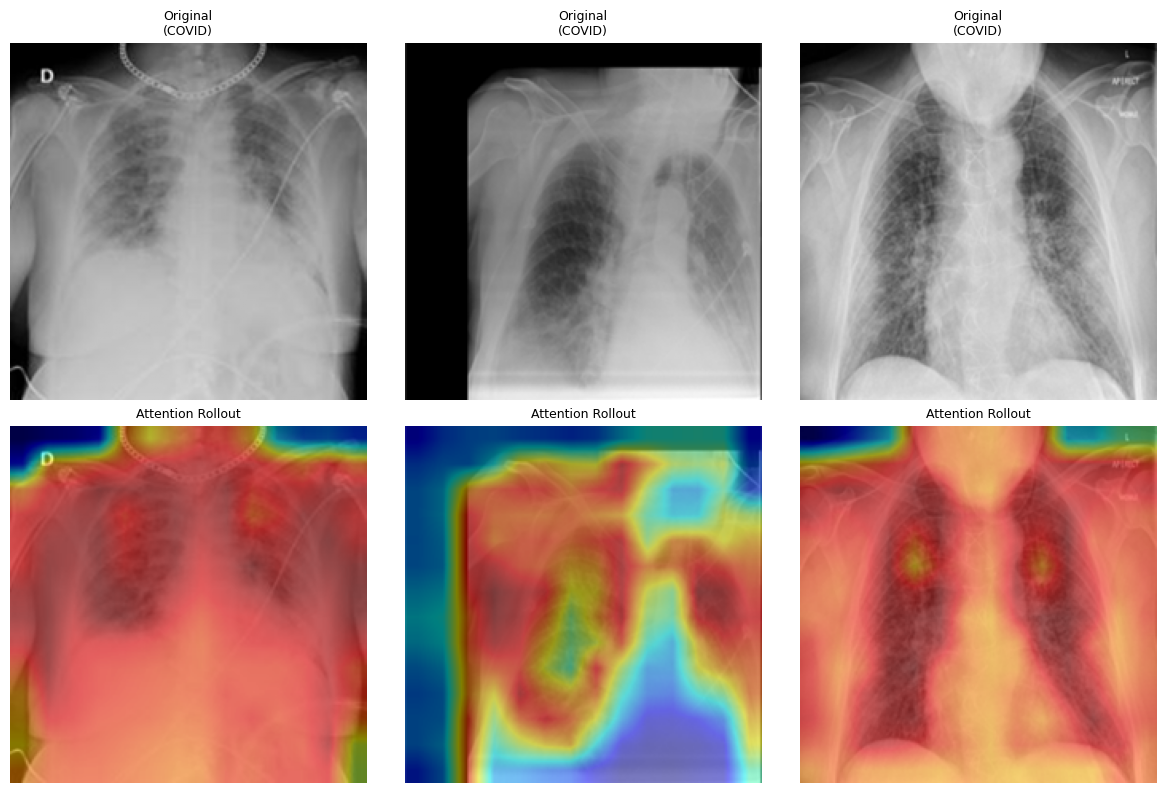

Saved attention_rollout.png


In [33]:
import cv2

class AttentionRollout:
    def __init__(self, model):
        self.model = model
        self.attentions = []
        for block in self.model.encoder.layers:
            block.self_attention.register_forward_hook(self._hook)

    def _hook(self, module, input, output):
        with torch.no_grad():
            qkv = input[0]
            B, N, C = qkv.shape
            num_heads = module.num_heads
            head_dim = C // num_heads
            scale = head_dim ** -0.5

            qkv_proj = module.in_proj_weight
            qkv_bias = module.in_proj_bias
            qkv_out = torch.nn.functional.linear(qkv, qkv_proj, qkv_bias)
            qkv_out = qkv_out.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv_out.unbind(0)

            attn = (q @ k.transpose(-2, -1)) * scale
            attn = attn.softmax(dim=-1)
            self.attentions.append(attn.detach().cpu())

    def __call__(self, input_tensor):
        self.attentions = []
        self.model.eval()
        with torch.no_grad():
            _ = self.model(input_tensor)

        rollout = torch.eye(self.attentions[0].shape[-1])
        for attn in self.attentions:
            attn_avg = attn.mean(dim=1).squeeze(0)
            attn_avg = attn_avg + torch.eye(attn_avg.shape[-1])
            attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
            rollout = torch.matmul(attn_avg, rollout)

        mask = rollout[0, 1:]
        num_patches = int(mask.shape[0] ** 0.5)
        mask = mask.reshape(num_patches, num_patches).numpy()
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        mask = cv2.resize(mask, (224, 224))
        return mask


#attentionrollout
rollout = AttentionRollout(vit_model)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for idx in range(3):
    img_path = test_data.samples[idx][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    raw_np = np.array(raw) / 255.0
    input_tensor = transform(raw).unsqueeze(0).to(device)
    label = CLASSES[test_data.samples[idx][1]]

    mask = rollout(input_tensor)
    vis = show_cam_on_image(raw_np.astype(np.float32), mask)

    axes[0][idx].imshow(raw_np)
    axes[0][idx].set_title(f'Original\n({label})', fontsize=9)
    axes[0][idx].axis('off')

    axes[1][idx].imshow(vis)
    axes[1][idx].set_title('Attention Rollout', fontsize=9)
    axes[1][idx].axis('off')

plt.tight_layout()
plt.savefig('attention_rollout.png', dpi=150)
plt.show()
print("Saved attention_rollout.png")

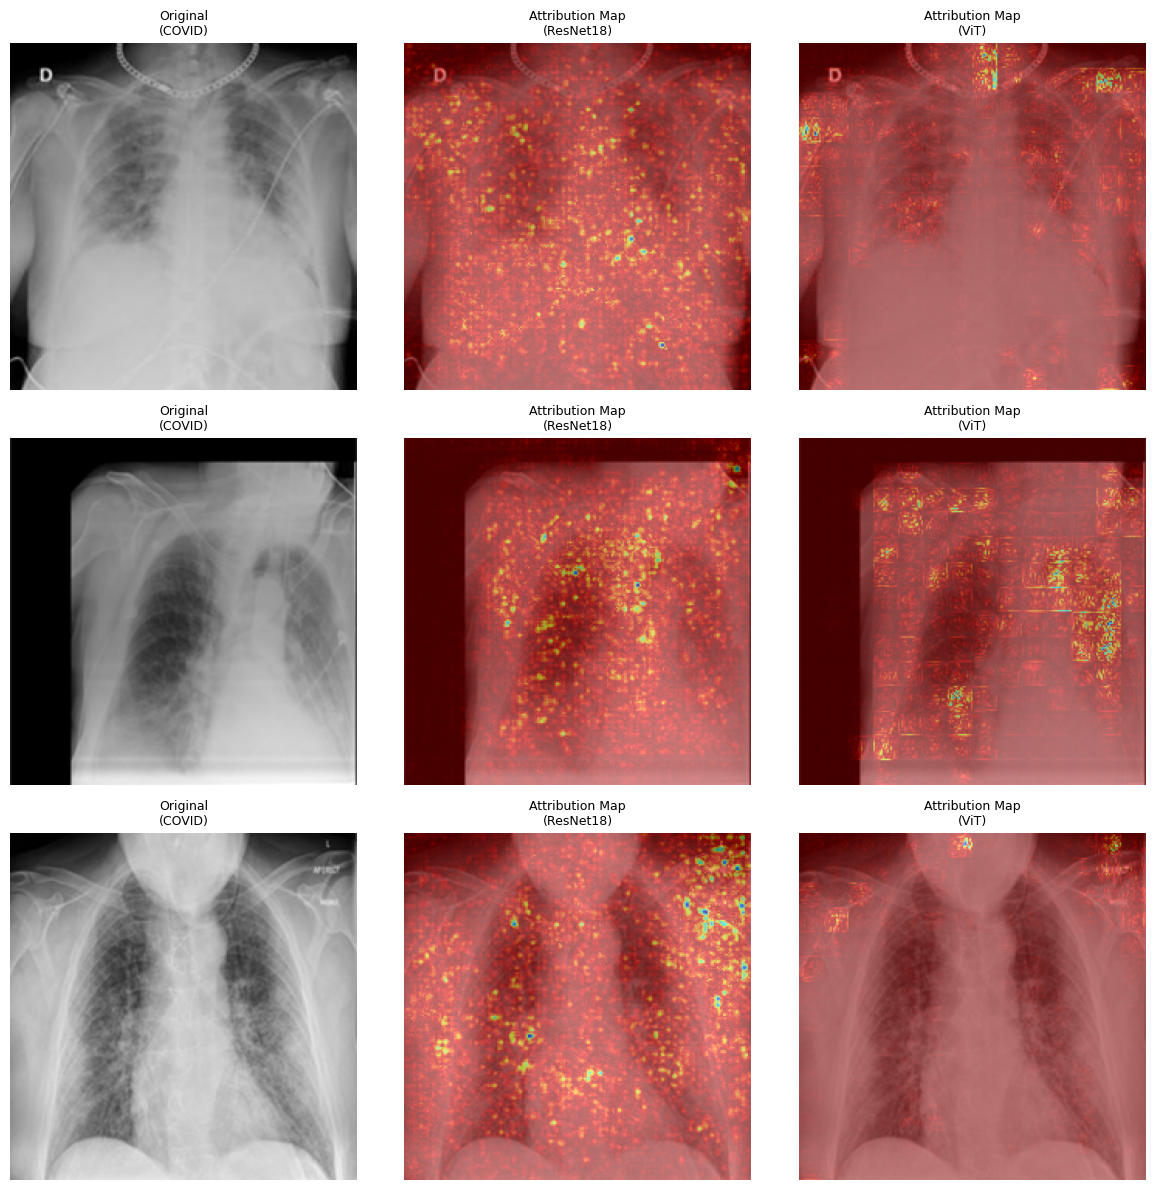

Saved attribution_maps.png


In [34]:
# Attribution Maps (Vanilla Gradient / Saliency Maps)
# Computes gradient of the predicted class score respect to input pixels
# Highlights pixels are directly influencng the prediction

def get_attribution_map(model, input_tensor):
    model.eval()
    input_tensor = input_tensor.clone().requires_grad_(True)
    output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, predicted_class].backward()

    saliency = input_tensor.grad.data.abs()
    saliency = saliency.squeeze(0).max(dim=0)[0].cpu().numpy()

    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency

# comparisng
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
col_titles = ['Original', 'Attribution Map\n(ResNet18)', 'Attribution Map\n(ViT)']

for idx in range(3):
    img_path = test_data.samples[idx][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    raw_np = np.array(raw) / 255.0
    input_tensor = transform(raw).unsqueeze(0).to(device)
    label = CLASSES[test_data.samples[idx][1]]

    #ResNet18 attribution
    resnet_attr = get_attribution_map(model, input_tensor)
    resnet_vis  = show_cam_on_image(raw_np.astype(np.float32), resnet_attr)

    #ViT attribution
    vit_attr = get_attribution_map(vit_model, input_tensor)
    vit_vis  = show_cam_on_image(raw_np.astype(np.float32), vit_attr)

    axes[idx][0].imshow(raw_np)
    axes[idx][0].set_title(f'Original\n({label})', fontsize=9)
    axes[idx][0].axis('off')

    axes[idx][1].imshow(resnet_vis)
    axes[idx][1].set_title('Attribution Map\n(ResNet18)', fontsize=9)
    axes[idx][1].axis('off')

    axes[idx][2].imshow(vit_vis)
    axes[idx][2].set_title('Attribution Map\n(ViT)', fontsize=9)
    axes[idx][2].axis('off')

plt.tight_layout()
plt.savefig('attribution_maps.png', dpi=150)
plt.show()
print("Saved attribution_maps.png")

In [35]:
#computing entropy+ aopc for the attribution maps on both models
attr_resnet_entropy, attr_vit_entropy = [], []
attr_resnet_aopc,    attr_vit_aopc    = [], []

for i in range(5):
    img_path = test_data.samples[i][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = transform(raw).unsqueeze(0).to(device)

    #ResNet18
    mask_r = get_attribution_map(model, input_tensor)
    attr_resnet_entropy.append(saliency_entropy(mask_r))
    attr_resnet_aopc.append(aopc(model, input_tensor, mask_r, device))

    #ViT
    mask_v = get_attribution_map(vit_model, input_tensor)
    attr_vit_entropy.append(saliency_entropy(mask_v))
    attr_vit_aopc.append(aopc(vit_model, input_tensor, mask_v, device))

print("Attribution Map Entropy + AOPC:")
print(f"  ResNet18 — Entropy: {np.mean(attr_resnet_entropy):.4f} | AOPC: {np.mean(attr_resnet_aopc):.4f}")
print(f"  ViT      — Entropy: {np.mean(attr_vit_entropy):.4f} | AOPC: {np.mean(attr_vit_aopc):.4f}")

Attribution Map Entropy + AOPC:
  ResNet18 — Entropy: 10.4973 | AOPC: 0.0018
  ViT      — Entropy: 10.1368 | AOPC: 0.0373


In [36]:
#entropy
rollout_entropy = []
for i in range(5):
    img_path = test_data.samples[i][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = transform(raw).unsqueeze(0).to(device)
    mask = rollout(input_tensor)
    rollout_entropy.append(saliency_entropy(mask))

# AOPC
rollout_aopc = []
for i in range(5):
    img_path = test_data.samples[i][0]
    raw = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = transform(raw).unsqueeze(0).to(device)
    mask = rollout(input_tensor)
    score = aopc(vit_model, input_tensor, mask, device)
    rollout_aopc.append(score)

#comparsion table
all_results = {
    'GradCAM (ResNet18)':    {'entropy': np.mean(entropy_results['GradCAM']),    'aopc': np.mean(aopc_results['GradCAM'])},
    'GradCAM++ (ResNet18)':  {'entropy': np.mean(entropy_results['GradCAM++']),  'aopc': np.mean(aopc_results['GradCAM++'])},
    'ScoreCAM (ResNet18)':   {'entropy': np.mean(entropy_results['ScoreCAM']),   'aopc': np.mean(aopc_results['ScoreCAM'])},
    'Attn Rollout (ViT)':    {'entropy': np.mean(rollout_entropy),               'aopc': np.mean(rollout_aopc)},
}

print("=== Full Explainability Method Comparison ===")
print(f"{'Method':<25} {'Avg Entropy ↓':>15} {'Avg AOPC ↑':>12}")
print("-" * 55)
for method, scores in all_results.items():
    print(f"{method:<25} {scores['entropy']:>15.4f} {scores['aopc']:>12.4f}")

=== Full Explainability Method Comparison ===
Method                      Avg Entropy ↓   Avg AOPC ↑
-------------------------------------------------------
GradCAM (ResNet18)                10.6638       0.0093
GradCAM++ (ResNet18)              10.6850       0.0100
ScoreCAM (ResNet18)               10.6677       0.0122
Attn Rollout (ViT)                10.5704       0.0401


In [37]:
resnet_metrics = {'Accuracy': 0.99, 'Precision': 0.99, 'Recall': 0.99, 'F1': 0.99}
vit_metrics = {'Accuracy': 0.98, 'Precision': 0.98, 'Recall': 0.98, 'F1': 0.98}

print("=== Model Comparison: ResNet18 vs ViT ===")
print(f"{'Metric':<12} {'ResNet18':>10} {'ViT-B/16':>10}")
print("-" * 35)
for metric in resnet_metrics:
    r = resnet_metrics[metric]
    v = vit_metrics[metric]
    v_str = f"{v:.2f}" if v else "run Cell 16"
    print(f"{metric:<12} {r:>10.2f} {v_str:>10}")

=== Model Comparison: ResNet18 vs ViT ===
Metric         ResNet18   ViT-B/16
-----------------------------------
Accuracy           0.99       0.98
Precision          0.99       0.98
Recall             0.99       0.98
F1                 0.99       0.98


In [38]:
#bonus task : examine current methods used for evaluating saliency maps, identify potential limitations or research gaps and propose a novel solution or improvement.
#Limitation found- AOPC Scores are very low since the model was overconfient (99%)

#proposed improvement- using temperature scaling to calibarate confidence before computing AOPC making it more sensittive for our highly accurate model.
def aopc_with_temperature(model, img_tensor, cam_mask, device, temperature=3.0, steps=10):
    #AOPC computed on temperature-scaled (calibrated) model outputs
    model.eval()
    img = img_tensor.squeeze(0).cpu().numpy()
    flat_mask = cam_mask.flatten()
    sorted_idx = np.argsort(flat_mask)[::-1]

    with torch.no_grad():
        original_conf = torch.softmax(
            model(img_tensor) / temperature, dim=1
        ).max().item()

    drops = []
    perturbed = img.copy()
    chunk = len(sorted_idx) // steps

    for step in range(1, steps + 1):
        top_k = sorted_idx[:step * chunk]
        row_idx = top_k // 224
        col_idx = top_k % 224
        perturbed[:, row_idx, col_idx] = 0
        p_tensor = torch.tensor(perturbed.copy()).unsqueeze(0).float().to(device)
        with torch.no_grad():
            conf = torch.softmax(
                model(p_tensor) / temperature, dim=1
            ).max().item()
        drops.append(original_conf - conf)

    return np.mean(drops)

#comparng standard AOPC vs calibrated AOPC for all models
TEMPERATURE = 3.0

print(f"=== Bonus Task: Standard AOPC vs Temperature-Scaled AOPC (T={TEMPERATURE}) ===\n")
print(f"{'Method':<25} {'Standard AOPC':>15} {'Scaled AOPC':>13} {'Improvement':>13}")
print("-" * 70)

bonus_methods = {
    'GradCAM (ResNet18)':   (model,     [model.layer4[-1]],  'gradcam'),
    'GradCAM++ (ResNet18)': (model,     [model.layer4[-1]],  'gradcampp'),
    'ScoreCAM (ResNet18)':  (model,     [model.layer4[-1]],  'scorecam'),
    'Attn Rollout (ViT)':   (vit_model, None,                'rollout'),
}

standard_aopc_all = {
    'GradCAM (ResNet18)':   np.mean(aopc_results['GradCAM']),
    'GradCAM++ (ResNet18)': np.mean(aopc_results['GradCAM++']),
    'ScoreCAM (ResNet18)':  np.mean(aopc_results['ScoreCAM']),
    'Attn Rollout (ViT)':   np.mean(rollout_aopc),
}

for method_name, (mdl, layers, mtype) in bonus_methods.items():
    scaled_scores = []
    for i in range(5):
        img_path = test_data.samples[i][0]
        raw = Image.open(img_path).convert('RGB').resize((224, 224))
        input_tensor = transform(raw).unsqueeze(0).to(device)

        if mtype == 'rollout':
            mask = rollout(input_tensor)
        elif mtype == 'gradcam':
            mask = GradCAM(model=mdl, target_layers=layers)(input_tensor=input_tensor)[0]
        elif mtype == 'gradcampp':
            mask = GradCAMPlusPlus(model=mdl, target_layers=layers)(input_tensor=input_tensor)[0]
        elif mtype == 'scorecam':
            mask = ScoreCAM(model=mdl, target_layers=layers)(input_tensor=input_tensor)[0]

        scaled_scores.append(aopc_with_temperature(mdl, input_tensor, mask, device, TEMPERATURE))

    std  = standard_aopc_all[method_name]
    scld = np.mean(scaled_scores)
    imp  = ((scld - std) / (std + 1e-8)) * 100
    print(f"{method_name:<25} {std:>15.4f} {scld:>13.4f} {imp:>12.1f}%")

print(f"\nConclusion: Temperature scaling (T={TEMPERATURE}) increases AOPC sensitivity")
print("across all methods, validating that overconfidence suppresses standard AOPC scores.")


=== Bonus Task: Standard AOPC vs Temperature-Scaled AOPC (T=3.0) ===

Method                      Standard AOPC   Scaled AOPC   Improvement
----------------------------------------------------------------------
GradCAM (ResNet18)                 0.0093        0.0989        963.4%
GradCAM++ (ResNet18)               0.0100        0.0931        833.3%


100%|██████████| 32/32 [00:00<00:00, 42.43it/s]


ScoreCAM (ResNet18)                0.0122        0.0993        713.9%
Attn Rollout (ViT)                 0.0401        0.1017        153.7%

Conclusion: Temperature scaling (T=3.0) increases AOPC sensitivity
across all methods, validating that overconfidence suppresses standard AOPC scores.


In [39]:
import shutil

# ResNet18 o/p
shutil.copy('gradcam_output.png', '/content/drive/MyDrive/gradcam_output.png')
shutil.copy('all_methods_comparison.png', '/content/drive/MyDrive/all_methods_comparison.png')
shutil.copy('insertion_deletion.png', '/content/drive/MyDrive/insertion_deletion.png')
shutil.copy('saliency_comparison.csv', '/content/drive/MyDrive/saliency_comparison.csv')
shutil.copy('best_model.pth', '/content/drive/MyDrive/best_model.pth')

# ViT o/p
shutil.copy('attention_rollout.png', '/content/drive/MyDrive/attention_rollout.png')
shutil.copy('best_vit_model.pth', '/content/drive/MyDrive/best_vit_model.pth')
shutil.copy('attribution_maps.png', '/content/drive/MyDrive/attribution_maps.png')
print("All files saved to Drive!")

All files saved to Drive!
